## Script to generate figure 3

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('.').resolve().parent))
import matplotlib.pyplot as plt
import module_ESN
import module_graph
import module_generate_data
from netgraph import Graph as plotGraph
from scipy.stats import beta
import matplotlib.pyplot as plt
import numpy as np
import netgraph
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib 
from netgraph._edge_layout import *
from netgraph._node_layout import get_fruchterman_reingold_layout, _remove_node_overlap
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from IPython.display import Image, display
import numpy as np
## other option that does print double edges for when netgraph doesn't work
import numpy as np
import networkx as nx

## function to compute all data for the step by step optimization and display 

def optimize_node(esn,  trials, proxy_nodes, is_goal=False):

    n = esn.n 
    num_action_nodes = len(esn.action_nodes)
    start_time = esn.proxy_discard*(not is_goal) + esn.goal_discard*is_goal
    end_time = start_time + esn.measure_time
    # define function to test an agent action 
    def test_agent_action(agent_action, action_value):
        """
        Test the average value of an action node if all other nodes are set to random values
        """
        proxy_samples    = np.asarray([])
        goal_samples    = np.asarray([])
        esn.reset_seed()
        for j in range(trials): 
            action_node_values = esn.get_directed_action_value(action_value , agent_action, actionsize = len(esn.action_nodes))
            states = esn.run(agent_values=action_node_values)
            proxy_samples = np.concatenate((proxy_samples,np.mean(states[start_time:end_time, proxy_nodes], axis=0)))
            goal_samples = np.concatenate((goal_samples,np.mean(states[esn.goal_discard:esn.goal_discard+esn.measure_time, esn.goal], axis=0)))
        if not is_goal:
            correl_node_goal = np.corrcoef(proxy_samples, goal_samples)[0, 1]
        else:
            correl_node_goal = 0

        return np.mean(proxy_samples), np.mean(goal_samples), correl_node_goal, proxy_samples, goal_samples
    max_proxy_value = -1
    goal_value_on_max_proxy = -1
    correlation_on_max_proxy = 0
    mean_proxy_list = []
    prox_samples = []
    _, _, _, proxy_base, goal_base = test_agent_action(0, 0)
    for i in range(num_action_nodes):
        for val in [-1, 1]:
            proxy_value, goal_value, correl_node_goal, proxy_samples, goal_samples = test_agent_action(i, val)
            mean_proxy_list.append(proxy_value) # for fig D 
            if proxy_value > max_proxy_value:
                max_proxy_value = proxy_value
                goal_value_on_max_proxy = goal_value
                correlation_on_max_proxy = correl_node_goal
                max_prox_samples = proxy_samples
                max_goal_samples = goal_samples
            prox_samples.append(proxy_samples)

    return (goal_value_on_max_proxy, max_proxy_value, correlation_on_max_proxy, mean_proxy_list, max_prox_samples, max_goal_samples, proxy_base, goal_base,prox_samples)

In [2]:
param_grid = {
    'n': [128], 
    'trials': [50],
    'proxy_discard': [50],
    'goal_discard': [50],
    'measure_time': [50],
    'alpha': [0.1],
    "avg_number_of_edges": [5],
    "seed": [0],
    "number_of_action_nodes": [16],
}
goal_color = mcolors.to_hex("tab:green")
proxy_color = mcolors.to_hex("greenyellow")
positive_color = mcolors.to_hex("tab:red")
negative_color = mcolors.to_hex("tab:blue")
#style_name = #'ggplot' # 'seaborn-v0_8-dark'
#plt.style.use(style_name)


param_ESN = dict(zip(param_grid.keys(), [param_grid[k][0] for k in param_grid.keys()]))
esn = module_ESN.EchoStateNetwork(param_ESN['n'],  alpha = param_ESN['alpha'], 
                            avg_number_of_edges=param_ESN['avg_number_of_edges'], proxy_discard=param_ESN['proxy_discard'],
                            goal_discard=param_ESN['goal_discard'], measure_time=param_ESN['measure_time'], 
                            seed=param_ESN['seed'],number_of_action_nodes=param_ESN['number_of_action_nodes'])
esn.reset_seed()
proxy_nodes, goal_value, proxy_value, correlations, bin_indices = module_generate_data.compute_proxy_nodes_from_esn(esn, param_ESN['trials'])


goal_value_on_max_proxy, max_proxy_value, correlation_on_max_proxy, mean_proxy_list, max_prox_samples, max_goal_samples, proxy_base, goal_base,prox_samples = optimize_node(esn,  param_ESN['trials'], proxy_nodes, is_goal=False)

print("initial goal value: ", np.mean(goal_base), goal_value)
print("initial proxy value: ",  np.mean(proxy_base))
print("max correlation: ", max(correlations))
print("max proxy value: ", max_proxy_value)
print("goal value on max proxy: ", goal_value_on_max_proxy)
print("correlation on max proxy: ", correlation_on_max_proxy)

print('Delta goal value: ', goal_value_on_max_proxy - goal_value)
print('Delta proxy value: ', max_proxy_value - np.mean(proxy_base))
print('Delta correlation: ', correlation_on_max_proxy - np.max(correlations))

initial goal value:  -0.0002825806074327361 -0.0036173954002399074
initial proxy value:  -0.001972821527145703
max correlation:  1.0
max proxy value:  0.024703935293259524
goal value on max proxy:  0.01785623842431133
correlation on max proxy:  0.8630832519698478
Delta goal value:  0.021473633824551235
Delta proxy value:  0.026676756820405226
Delta correlation:  -0.1369167480301522


Graph saved to figures_output/graph_example.png


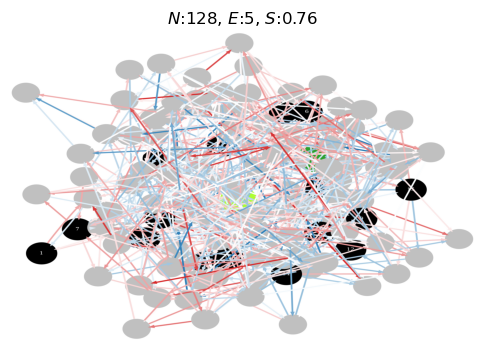

In [3]:
from graphviz import Digraph
from PIL import Image

def t256(x):
    return int(256*x)

def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

def plot_graph_cool_esn_graphviz(ax,ESN, filename="esn_graph", show_numbers=False, proxy_node=None, mode = 'sfdp', labels = True):
    G = module_graph.outputgraph(ESN.W)
    n = max(G.nodes())
    cmap =matplotlib.colors.LinearSegmentedColormap.from_list("", [negative_color,"white", positive_color]) #'coolwarm'
    # Create Graphviz directed graph
    dot = Digraph(engine=mode)   # or "sfdp" 
    # ---- NODE COLORS ----
    colors = {
        node:
            (goal_color if node == n else
             'gray' if ESN.number_of_action_nodes <= node < n else
             'black')
        for node in G.nodes()
    }

    sizes = {
        node:
            ("1.2" if node == n else
             "0.9" if ESN.number_of_action_nodes <= node < n else
             "1.0")
        for node in G.nodes()
    }

    if proxy_node is not None:
        colors[proxy_node] = proxy_color
        sizes[proxy_node] = "1.2"

    # ---- LABELS ----
    labels = {}
    for node in G.nodes():
        if not show_numbers:
            labels[node] = ""
        else:
            if node < ESN.number_of_action_nodes:
                labels[node] = str(node)
            elif node == ESN.n - 1:
                labels[node] = "G"
            elif node == proxy_node:
                labels[node] = "P"
            else:
                labels[node] = ""

    # ---- ADD NODES ----
    for node in G.nodes():
        dot.node(
            str(node),
            label=labels[node],
            style="filled",
            fillcolor=colors[node],
            width=sizes[node],
            height=sizes[node],
            fontcolor="white",
            penwidth="0"
        )

    # ---- ADD EDGES ----
    for u, v, data in G.edges(data=True):
        w = data.get("weight", 0)
        L = list(map(t256, mcolors.to_rgb(cmap(w/2+0.5))))
        edge_color =  '#%02x%02x%02x' % (L[0], L[1], L[2])
        penwidth = "4"  # optional: thickness based on magnitude

        dot.edge(
            str(u),
            str(v),
            color=edge_color,
            penwidth=penwidth,
            arrowsize="0.7"
        )

    # ---- EXPORT ----
    filename = "figures_output/"+filename
    dot.render(filename, format="png", cleanup=True)
    print(f"Graph saved to {filename}.png")
    

    # ---- PLOT ----
    image = open_image_local(filename+".png")
    
    ax.imshow(image, aspect='auto')
    ax.set_title(r'$N$:' + str(ESN.n)+ r", $E$:"+ str(ESN.avg_number_of_edges)+ r", $S$:"+ str(ESN.spectral_radius)[:4])
    ax.axis("off")

filename =  "graph_example"
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_graph_cool_esn_graphviz(ax, esn,filename,0.3,  proxy_node=proxy_nodes[0], mode = "sfdp")
# cool mods = osage, sfdp 

In [4]:
pip install graphviz


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


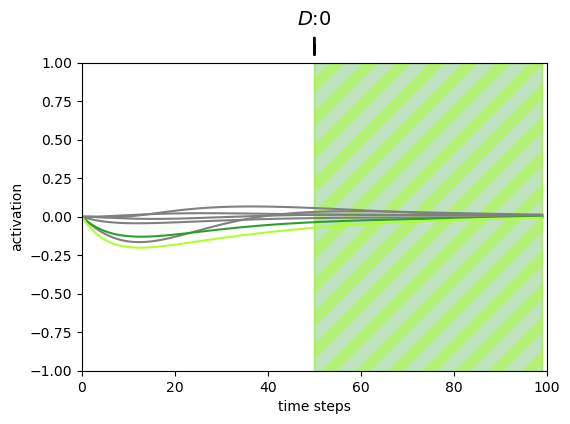

In [5]:
import matplotlib as mpl
def draw_brace(ax, xspan, yy, text,dpidiff):
    """Draws an annotated brace on the axes."""
    xmin, xmax = xspan
    xspan = xmax - xmin
    leng = 0.06
    fs = 14.0
    div = dpidiff*180*xspan/fs
    mid = xmin + xspan/2
    ymin, ymax = ax.get_ylim()
    yspan = ymax - ymin
    
    ax.annotate(text, xy=(mid, yy), xytext=(mid, yy+leng), xycoords='axes fraction', 
            fontsize=fs, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', color='white'),
            arrowprops=dict(arrowstyle='-[, widthB='+str(div)+', lengthB=0.5', lw=2.0, color='k'))
    

    ax_xmin, ax_xmax = ax.get_xlim()
    xax_span = ax_xmax - ax_xmin

    resolution = int(xspan/xax_span*100)*2+1 # guaranteed uneven
    beta = 300./xax_span # the higher this is, the smaller the radius

    x = np.linspace(xmin, xmax, resolution)
    x_half = x[:int(resolution/2)+1]
    y_half_brace = (1/(1.+np.exp(-beta*(x_half-x_half[0])))
                    + 1/(1.+np.exp(-beta*(x_half-x_half[-1]))))
    y = np.concatenate((y_half_brace, y_half_brace[-2::-1]))
    y = yy + (.05*y - .01)*yspan # adjust vertical position



mpl.rcParams['hatch.linewidth'] = 8.0
def plot_temporal(ax,ESN, proxy_node = None, number_displayed= 5, labels = True, filename =filename,dpidiff = 1):
    G = module_graph.outputgraph(ESN.W)
    n =ESN.W.shape[0]-1
    colors = { node:  goal_color*(node == n)+  'gray'*(ESN.number_of_action_nodes<=node and node<n) + 'k'*(node <ESN.number_of_action_nodes )   for node in G.nodes() }
    esn.reset_seed()
    actions = esn.get_base_action_value(len(ESN.action_nodes))
    states = ESN.run( agent_values=actions)
    displayed  = list(np.random.randint(16,n,number_displayed)) +[n]
    for k in displayed:
        p = ax.plot(states[:, k], color = colors[k])
    if proxy_node:
        p = ax.plot(states[:, proxy_node], color = proxy_color)
    ax.set_xlabel('time steps')
    if labels:
        ax.set_ylabel('activation')
    ax.set_ylim(-1,1)
    
    g = ESN.goal_discard
    p =  ESN.proxy_discard
    m = ESN.measure_time
    p_relative = p/(g+m)
    g_relative = g/(g+m)
    if g ==p:
        ax.fill_between(range(g , g+m  ),-1, 1, color = goal_color, alpha=0.3, label ="goal evaluation")
        ax.fill_between(range(p , p+m  ),-1, 1, color="none", hatch="/", edgecolor=proxy_color, alpha=0.5)
        ax.fill_between(range(0, 0  ),-1, 1,  color = proxy_color, alpha=0.5, label ="proxy evaluation")
        draw_brace(ax, (p_relative,g_relative), 1.05,r'$D$:'+str(g-p),dpidiff)
    else:
        ax.fill_between(range(g , g+m  ),-1, 1,  color = goal_color, alpha=0.3, label ="goal evaluation")
        ax.fill_between(range(p , p+m  ),-1, 1,  color = proxy_color, alpha=0.5, label ="proxy evaluation")
        draw_brace(ax,  (p_relative,g_relative), 1.05,r'$D$:'+str(g-p),dpidiff)
    ax.set_xlim(0,g+m)
    #ax.legend(loc =(0.4,0))
    if filename:
        plt.savefig("figures_output/"+filename + ".svg", format="svg", bbox_inches="tight", transparent=True, dpi = 500)
fig, ax = plt.subplots(1, 1, figsize=(6, 4),dpi = 100)
plot_temporal(ax,esn, proxy_node=proxy_nodes[0],dpidiff = 1)

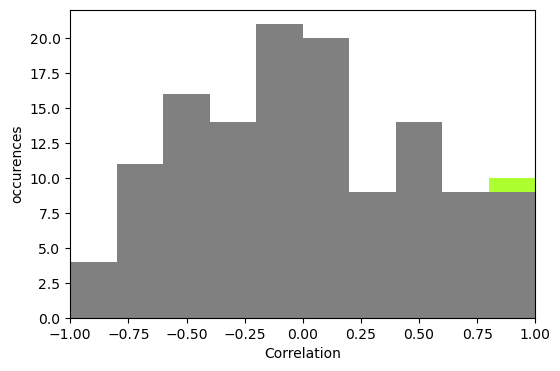

In [6]:
def plot_correlations(correlations,ax, labels = True, filename = ""):
    L = sorted(correlations)
    bins = 10
    ax.hist([L[:-1], L[-1:]], color =['gray',proxy_color], stacked = True, bins = [2*k/bins-1 for k in range(bins+1)])
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Correlation')
    if labels:
        ax.set_ylabel('occurences')
    if filename:
        plt.savefig("figures_output/"+filename+ ".svg", format="svg", bbox_inches="tight", transparent=True)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

plot_correlations(correlations,ax)

In [7]:
def ESN_4(seed = 0, number_of_action_nodes = 16):
    param_grid = {
        'n': [128, 256, 512, 1024], 
        'trials': [50],
        'proxy_discard': [50],
        'goal_discard': [50, 150, 250, 450],
        'measure_time': [50],
        'alpha': [0.1],
        "avg_number_of_edges": [5,10,20,40],
        "seed": [1],
        "number_of_action_nodes": [16]
    }
    ESN_list = []
    proxy_list = []
    correlation_list = []
    variable_params = {k: param_grid[k] for k in param_grid.keys() if len(param_grid[k])>1}
    param_ESN = {k: param_grid[k][0] for k in param_grid.keys() if len(param_grid[k])==1}
    print(variable_params)
    for j in range(4):
        param_ESN.update( {k: param_grid[k][j] for k in variable_params.keys()})
        esn = module_ESN.EchoStateNetwork(param_ESN['n'], alpha = param_ESN['alpha'], 
                                    avg_number_of_edges=param_ESN['avg_number_of_edges'], proxy_discard=param_ESN['proxy_discard'],
                                    goal_discard=param_ESN['goal_discard'], measure_time=param_ESN['measure_time'], 
                                    seed=seed,number_of_action_nodes=number_of_action_nodes)
        proxy_nodes, goal_value, proxy_value, correlations, bin_indices = module_generate_data.compute_proxy_nodes_from_esn(esn, param_ESN['trials'])
        
        ESN_list.append(esn)
        proxy_list.append(proxy_nodes[0])
        correlation_list.append(correlations)
    return ESN_list, proxy_list, correlation_list

## Full figure now

{'n': [128, 256, 512, 1024], 'goal_discard': [50, 150, 250, 450], 'avg_number_of_edges': [5, 10, 20, 40]}
Graph saved to figures_output/graph_fig3_0.png
Graph saved to figures_output/graph_fig3_1.png
Graph saved to figures_output/graph_fig3_2.png
Graph saved to figures_output/graph_fig3_3.png


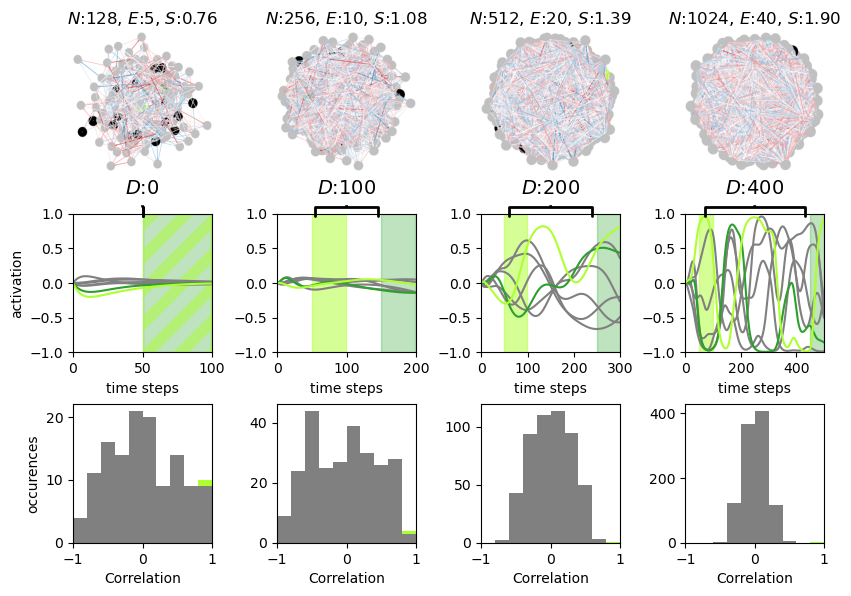

In [8]:
ESN_list, proxy_list, correlation_list = ESN_4()
fig = plt.figure(layout = "constrained", figsize =(8.27,11.69/2))
gs = gridspec.GridSpec(3, 4, figure=fig)
for j in range(4):
    ax1 = fig.add_subplot(gs[0, j])
    ax2 = fig.add_subplot(gs[1, j])
    ax3 = fig.add_subplot(gs[2, j])
    esn, proxy_node, correlation = ESN_list[j], proxy_list[j], correlation_list[j] 
    filename = "graph_fig3_"  + str(j)
    plot_graph_cool_esn_graphviz(ax1, esn,filename,0.3,  proxy_node=proxy_nodes[0], mode = "sfdp", labels = j == 0)
    filename = "temporal_fig3_"  + str(j)
    plot_temporal(ax2,esn, proxy_node=proxy_nodes[0], labels = j == 0, filename="", dpidiff = 1/4)
    filename = "correlation_fig3_"  + str(j)
    plot_correlations(correlation,ax3, labels = j == 0, filename="")
plt.savefig("figures_output/fig3.svg", format="svg", bbox_inches="tight", transparent=True)




# Generate all small figures


{'n': [128, 256, 512, 1024], 'goal_discard': [50, 150, 250, 450], 'avg_number_of_edges': [5, 10, 20, 40]}


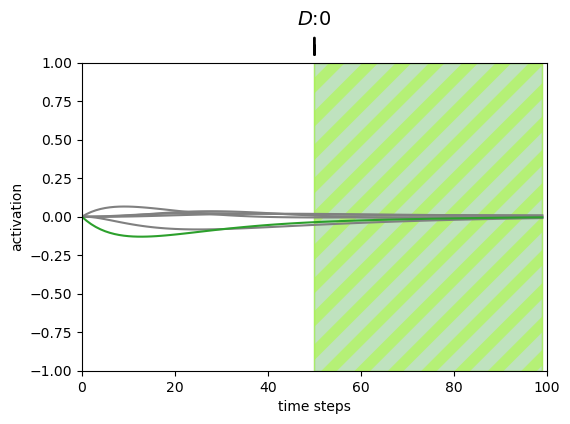

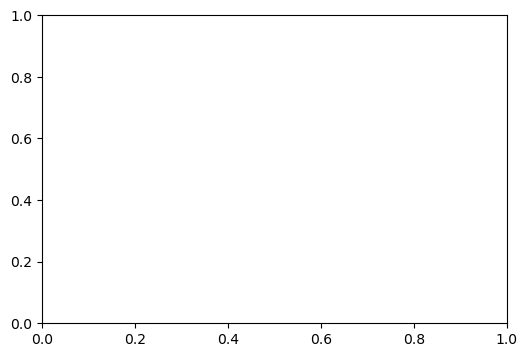

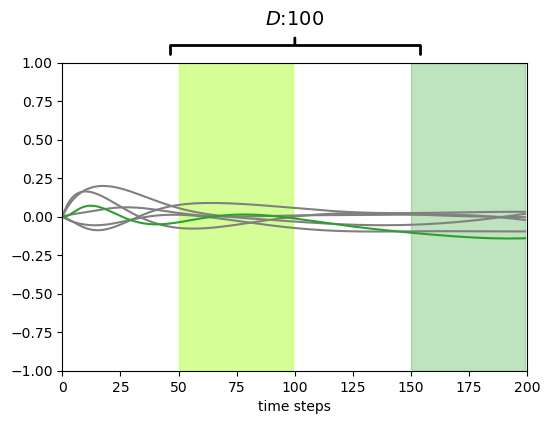

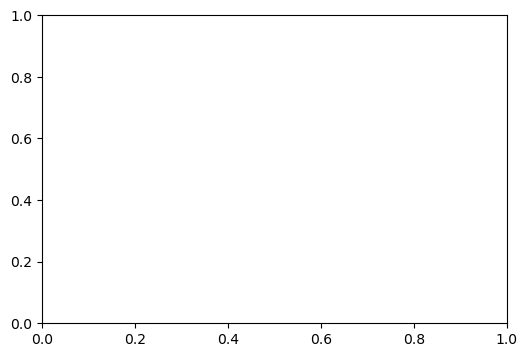

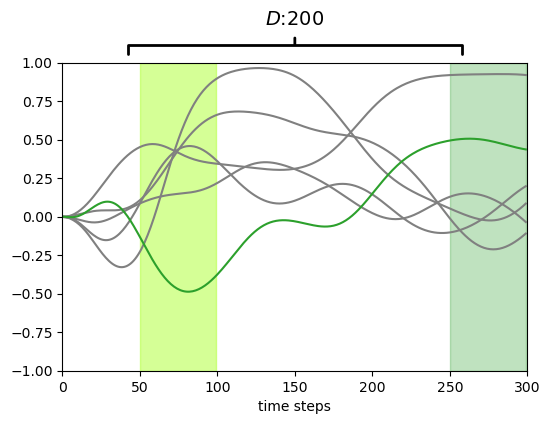

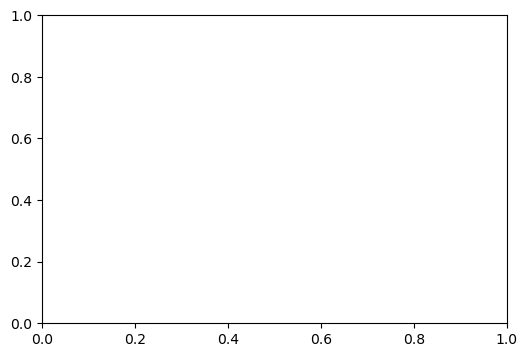

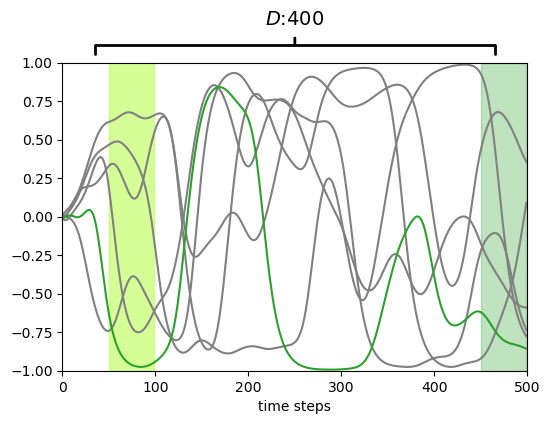

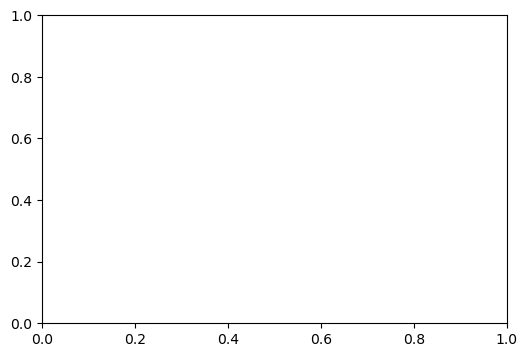

In [9]:

ESN_list, proxy_list, correlation_list = ESN_4()

for j in range(4):

    esn, proxy_node, correlation = ESN_list[j], proxy_list[j], correlation_list[j] 
    filename = "temporal_fig3_"  + str(j)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    plot_temporal(ax,esn, labels = j == 0, filename=filename)
    filename = "correlation_fig3_"  + str(j)
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    plot_correlations(correlation,ax3, labels = j == 0, filename=filename)




In [10]:
proxy_nodes[0]

121

In [11]:
np.mean(range(1,6))

3.0